# Lab 02: Credit Ratings

---
author: Trishla Nair
date: September 13, 2024
embed-resources: true
---

## Introduction

Our goal is to try an create a regression model for a client's credit based on their demographic and income.

## Methods

In [207]:
# imports
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from joblib import dump

### Data

In [208]:
# load data
credit_train = pd.read_csv("https://cs307.org/lab-02/data/credit-train.csv")
credit_test = pd.read_csv("https://cs307.org/lab-02/data/credit-test.csv")
credit_train

,Rating,Income,Age,Education,Gender,Student,Married,Ethnicity
0,257.0,44.473,81.0,16.0,Female,No,No,NaN
1,353.0,41.532,50.0,NaN,Male,No,Yes,Caucasian
2,388.0,16.479,26.0,16.0,Male,NaN,No,NaN
3,321.0,10.793,29.0,13.0,Male,No,No,Caucasian
4,367.0,76.273,65.0,14.0,Female,No,Yes,Caucasian
...,...,...,...,...,...,...,...,...
251,268.0,26.370,78.0,11.0,Male,No,Yes,Asian
252,433.0,26.427,50.0,15.0,Female,Yes,Yes,Asian
253,259.0,12.031,58.0,18.0,Female,NaN,Yes,Caucasian
254,335.0,80.861,29.0,15.0,Female,No,Yes,Asian


In [209]:
# summary statistics
credit_train.shape

(256, 8)

In [210]:
nan_df = credit_train.isna().sum()
nan_df

Rating        0
Income        0
Age          33
Education    25
Gender        6
Student      24
Married       0
Ethnicity    25
dtype: int64

In [211]:
# note numeric and categorical features
categorical_features = credit_train.select_dtypes(include="object").columns
numeric_features = credit_train.select_dtypes(exclude="object").columns

# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
preprocessor.fit(credit_train)

c_train = pd.DataFrame(
    preprocessor.transform(credit_train),
    columns=preprocessor.get_feature_names_out(),
)

In [212]:
c_train

,num__Rating,num__Income,num__Age,num__Education,cat__Gender_Female,cat__Student_Yes,cat__Married_Yes,cat__Ethnicity_Asian,cat__Ethnicity_Caucasian
0,-0.609745,0.035690,1.568608,0.837777,1.0,0.0,0.0,0.0,1.0
1,0.036276,-0.052062,-0.355755,0.000000,0.0,0.0,1.0,0.0,1.0
2,0.271804,-0.799586,-1.845584,0.837777,0.0,0.0,0.0,0.0,1.0
3,-0.179065,-0.969244,-1.659356,-0.149603,0.0,0.0,0.0,0.0,1.0
4,0.130487,0.984530,0.575388,0.179524,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
251,-0.535722,-0.504462,1.382379,-0.807856,0.0,0.0,1.0,1.0,0.0
252,0.574626,-0.502761,-0.355755,0.508650,1.0,1.0,1.0,1.0,0.0
253,-0.596287,-0.932304,0.140855,1.496030,1.0,0.0,1.0,0.0,1.0
254,-0.084853,1.121425,-1.659356,0.508650,1.0,0.0,1.0,1.0,0.0


The dataset has a response column of rating and the other features are made up of numeric and categorical data.

In [213]:
print(credit_train["Rating"].mean(), credit_train["Rating"].std())

347.609375 148.8931046679028


In [214]:
credit_train.pivot_table(index = ['Student'], values = ['Rating'], aggfunc = ['count', 'mean', 'std'])

,count,mean,std
,Rating,Rating,Rating
Student,,,
No,213,349.511737,148.003525
Yes,19,338.473684,149.164476


In [215]:
c = credit_train.pivot_table(index = ['Married'], values = ['Rating'], aggfunc = ['count', 'mean', 'std']).reset_index()
c

,Married,count,mean,std
,,Rating,Rating,Rating
0,No,98,329.397959,132.039649
1,Yes,158,358.905063,157.797935


In [216]:
credit_train['Age'].corr(credit_train['Rating'])

0.1430318874061348

In [217]:
credit_train['Income'].corr(credit_train['Rating'])

0.7708422040157118

In [218]:
c = credit_train.pivot_table(index = ['Income', 'Age', 'Education'], values = 'Rating', aggfunc='mean').reset_index()
c

,Income,Age,Education,Rating
0,10.403,43.0,7.0,310.0
1,10.588,66.0,13.0,296.0
2,10.742,57.0,15.0,156.0
3,10.793,29.0,13.0,321.0
4,10.852,30.0,9.0,296.0
...,...,...,...,...
194,135.118,81.0,15.0,747.0
195,146.183,66.0,15.0,682.0
196,158.889,62.0,17.0,805.0
197,182.728,98.0,17.0,982.0


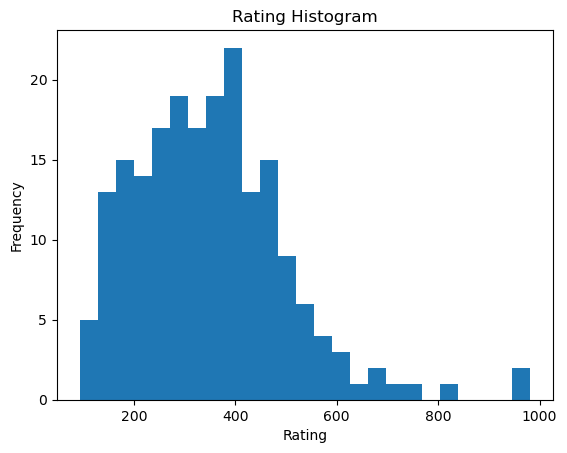

In [219]:
# visualizations
plt.hist(c['Rating'], bins=25)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Histogram')
plt.show()

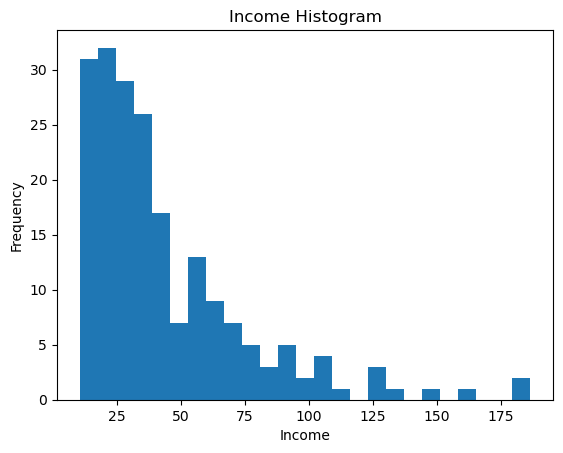

In [220]:
plt.hist(c['Income'], bins=25)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Income Histogram')
plt.show()

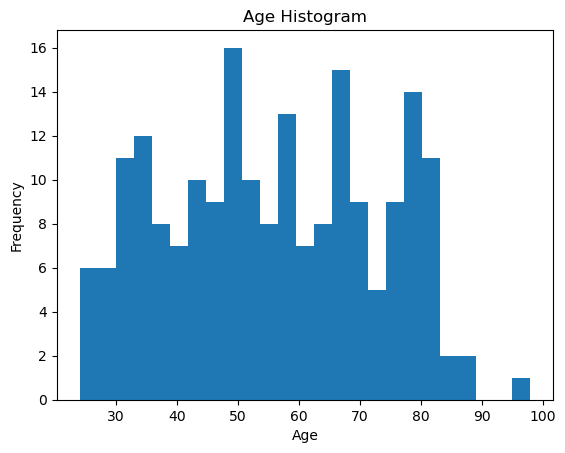

In [221]:
plt.hist(c['Age'], bins=25)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Histogram')
plt.show()

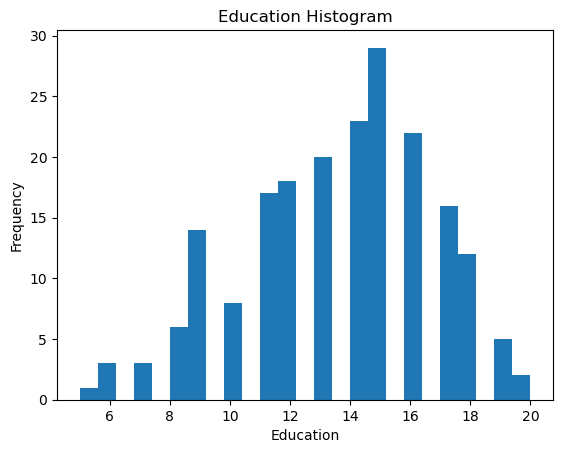

In [222]:
plt.hist(c['Education'], bins=25)
plt.xlabel('Education')
plt.ylabel('Frequency')
plt.title('Education Histogram')
plt.show()

The histograms above examine the numerical features of the data and each oberservation's rating. Education and Age appear to be close to normal, however Income and Rating are skewed negatively.

### Models

In [223]:
# process data for ML

# train models
# create X and y for train
x_train = credit_train.drop("Rating", axis=1)
y_train = credit_train["Rating"]

# create X and y for test
x_test = credit_test.drop("Rating", axis=1)
y_test = credit_test["Rating"]

In [224]:
# define numeric and categorical features
numeric_features = ['Income', 'Age']
categorical_features = ['Education', 'Gender', 'Student']

#define preprocessing steps for num features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
    ]
)

#define preprocessing steps for cat features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore')),
    ]
)

#combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

#create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor()),
    ]
)

#define parameter grid
param_grid = {
    'regressor__n_neighbors': range(1, x_train.shape[0]-51, 2),
    'regressor__metric': ['euclidean', 'manhattan'],
}

#setup grid with cv
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error')
mod = grid_search.fit(x_train, y_train)

The dataset is divided into a training and testing data. The training data is then wrangled and nan observations are filled either by mean for numerical columns or most_frequent for categorcal columns. This dataset is then input into a grid search method.

## Results

In [228]:
# report model metrics
dump(mod, "credit-ratings.joblib")

['credit-ratings.joblib']

The resulting model has a mean squared error of 112.09 on the test data. The data is a bit spread out which supports the initial histograms. Considering that the dataset involves the usage of large values, a high mean squared error can be expected.

## Discussion

I think further vetting of the features might be required or further vetting of the observations. A skewed credit rating might indicate issues with the data or a bigger issues that should be looked into.

### Conclusion

Based on the model used, I recommend it might not be wise to use this model. A better model to would be a simpler regression model that accounts for dummy variables. It is not necessary that this model is linear.